### Chargement des données avec pandas

## Source des données et licence

Les données utilisées dans ce notebook proviennent d'[Open Food Facts](https://world.openfoodfacts.org).

- La structure de la base de données est distribuée sous licence **Open Database License (ODbL)**.
- Le contenu individuel (données produits) est distribué sous licence **Database Contents License (DbCL) 1.0**.
- Les éventuelles images de produits sont distribuées sous licence **Creative Commons Attribution-ShareAlike (CC BY-SA)**.

Conformément à ces licences, ce travail crédite Open Food Facts comme source des données.
Tout jeu de données dérivé partagé publiquement (par exemple `produits_france.parquet`)
est repartagé sous les mêmes conditions (ODbL / DbCL).

In [49]:
"""
Loads all products sold in France directly into memory, in a pandas
DataFrame — without ever loading the full 7 GB file at once.

We read the file in batches, keep only the rows concerning France, and
assemble everything into a single DataFrame at the end.
"""

import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd

SOURCE_FILE = "../data/food.parquet"   # <-- adjust as needed
BATCH_SIZE = 200_000

# Check the format of countries_tags (list or string)
parquet_file = pq.ParquetFile(SOURCE_FILE)
column_type = parquet_file.schema_arrow.field("countries_tags").type
is_list = pa.types.is_list(column_type) or pa.types.is_large_list(column_type)
print("countries_tags column considered a list:", is_list)

def contains_france(value):
    if value is None:
        return False
    if is_list:
        return "en:france" in value
    else:
        return "en:france" in [tag.strip() for tag in value.split(",")]

chunks = []
useful_columns = [
    'product_name',
    'brands',
    'code',
    'nutriments',
    'nutriscore_score',
    'countries_tags',
    'ingredients'
]
rows_read = 0

for batch in parquet_file.iter_batches(batch_size=BATCH_SIZE, columns=useful_columns):
    batch_dataframe = batch.to_pandas()
    rows_read += len(batch_dataframe)

    mask = batch_dataframe["countries_tags"].apply(contains_france)
    filtered_dataframe = batch_dataframe[mask]
    if len(filtered_dataframe) > 0:
        chunks.append(filtered_dataframe)

    rows_found = sum(len(chunk) for chunk in chunks)
    print(f"  {rows_read:,} rows read, {rows_found:,} France rows found", end="\r")

# Final assembly into a single DataFrame, ready to be analyzed
france_dataframe = pd.concat(chunks, ignore_index=True)

print(f"\n\nDone: {len(france_dataframe):,} France products loaded into memory")
print("Memory used:", round(france_dataframe.memory_usage(deep=True).sum() / 1e6, 1), "MB")
print(france_dataframe.shape)

# Save the France products to avoid rescanning everything
france_dataframe.to_parquet('../data/produits_france.parquet')

# For the rest of the assignment, it will be enough to do
# france_dataframe = pd.read_parquet('../data/produits_france.parquet')

countries_tags column considered a list: True
  4,636,471 rows read, 1,247,336 France rows found

Done: 1,247,336 France products loaded into memory
Memory used: 2544.7 MB
(1247336, 7)


<class 'pandas.DataFrame'>
RangeIndex: 1247336 entries, 0 to 1247335
Data columns (total 7 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   product_name      1247336 non-null  object 
 1   brands            704417 non-null   str    
 2   code              1247336 non-null  str    
 3   nutriments        937673 non-null   object 
 4   nutriscore_score  463757 non-null   float64
 5   countries_tags    1247336 non-null  object 
 6   ingredients       358911 non-null   str    
dtypes: float64(1), object(3), str(3)
memory usage: 2.0+ GB
count    463757.000000
mean         11.173912
std          10.085373
min         -17.000000
25%           3.000000
50%          11.000000
75%          19.000000
max          53.000000
Name: nutriscore_score, dtype: float64
The missing rate on the nutriscore_score column is: 62.82
There are 445 products considered "out of range" for the Nutri-Score value, i.e. 0.04 %
445
                         

<Axes: >

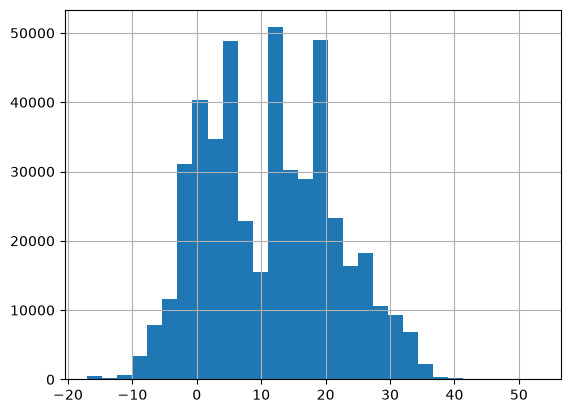

In [ ]:
"""
TP2 - "Distributions" step
"""
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt

france_dataframe = pd.read_parquet('../data/produits_france.parquet')

# ---------------------------------------------------------------------------
# 0) Quick overview: types, non-missing values per column
# ---------------------------------------------------------------------------
france_dataframe.info()

# Distribution of the Nutri-Score
print(france_dataframe['nutriscore_score'].describe())

nutriscore_count = france_dataframe['nutriscore_score'].describe()['count']
nutriscore_missing_rate = (1 - nutriscore_count / len(france_dataframe)) * 100

print(f'The missing rate on the nutriscore_score column is: {nutriscore_missing_rate:.2f} %')

# Visualization of products with an "out of range" score
out_of_range = france_dataframe[(france_dataframe["nutriscore_score"] < -15) | (france_dataframe["nutriscore_score"] > 40)]
out_of_range_rate = (len(out_of_range) / len(france_dataframe)) * 100
print(f'There are {len(out_of_range)} products considered "out of range" for the Nutri-Score value, i.e. {out_of_range_rate:.2f} %')
print(len(out_of_range))
print(out_of_range[["product_name", "nutriscore_score"]].head(10))

france_dataframe['nutriscore_score'].hist(bins=30)

In [51]:
# Distribution of nutrients

# First step: extract the relevant information
def extract_nutrients(nutrients_list, names_to_find):
    result = {column_name: None for column_name in names_to_find.values()}

    if nutrients_list is None:
        return result

    for item in nutrients_list:
        name = item.get('name')

        if name in names_to_find:
            result[names_to_find[name]] = item.get('100g')

    return result

names_to_find = {
    'energy-kcal': 'energy_kcal_100g',
    'sugars': 'sugars_100g',
    'salt': 'salt_100g'
}

extracted_nutrients = pd.DataFrame(
    france_dataframe['nutriments'].apply(lambda x: extract_nutrients(x, names_to_find)).tolist()
)

france_dataframe = pd.concat(
    [france_dataframe.reset_index(drop=True), extracted_nutrients.reset_index(drop=True)],
    axis=1
)

france_dataframe[['energy_kcal_100g', 'sugars_100g', 'salt_100g']].head()

,energy_kcal_100g,sugars_100g,salt_100g
0,617.0,32.0,0.01
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,200.0,26.6,0.10


In [53]:
# Quick check to make sure the code works correctly
import random

test_indices = random.sample(range(len(france_dataframe)), 30)

for i in test_indices:
    raw = france_dataframe['nutriments'].iloc[i]
    expected_value = None

    if raw is not None:
        for item in raw:
            if item.get('name') == 'sugars':
                expected_value = item.get('100g')

    obtained_value = france_dataframe['sugars_100g'].iloc[i]

    if expected_value != obtained_value and not (pd.isna(expected_value) and pd.isna(obtained_value)):
        print(f'MISMATCH at row {i}: expected {expected_value}, got {obtained_value}')

print('Verification completed')

Verification completed


In [54]:
def analyze_distribution(dataframe, column, min_value=0, max_value=100, display_name=None):
    """
    Complete analysis of a "g/100g"-type numeric column:
    describe, missing rate, impossible values, worst cases, histogram.
    Returns a dict of results reusable for the final synthesis.
    """
    display_name = display_name or column
    print(f"--- {display_name} ---")

    stats = dataframe[column].describe()
    print(stats)

    missing_rate = (1 - stats['count'] / len(dataframe)) * 100
    print(f"Missing rate on {column}: {missing_rate:.2f} %")

    impossible_values = dataframe[
        (dataframe[column] < min_value) | (dataframe[column] > max_value)
    ]
    impossible_rate = (len(impossible_values) / len(dataframe)) * 100
    print(f"{len(impossible_values)} products have an impossible {display_name} value, "
          f"i.e. {impossible_rate:.4f} %")

    sorted_impossible_values = impossible_values.sort_values(column, ascending=False)
    print(sorted_impossible_values[['product_name', column]].head(5))

    if len(sorted_impossible_values) > 0:
        worst_index = sorted_impossible_values.index[0]
        print("Raw data for the worst row:")
        print(dataframe['nutriments'].loc[worst_index])

    dataframe[column].hist(bins=30)
    plt.title(f"Distribution of {display_name}")
    plt.show()

    return {
        "column": column,
        "missing_rate": missing_rate,
        "nb_impossible_values": len(impossible_values),
        "impossible_rate": impossible_rate,
        "impossible_values": impossible_values,
    }

In [55]:
def extract_main_name(names_list):
    if names_list is None or len(names_list) == 0:
        return None
    for item in names_list:
        if item.get("lang") == "main":
            return item.get("text")
    return names_list[0].get("text")  # in case there is no "main" entry, take the first one

734820 unique product names
--- sugar ---
count    8.807820e+05
mean     1.333721e+27
std      1.251697e+30
min      0.000000e+00
25%      6.000000e-01
50%      3.500000e+00
75%      1.978000e+01
max      1.174717e+33
Name: sugars_100g, dtype: float64
Missing rate on sugars_100g: 29.39 %
47 products have an impossible sugar value, i.e. 0.0038 %
                                              product_name   sugars_100g
908280   [{'lang': 'main', 'text': 'Ristretto decaffein...  1.174717e+33
67649    [{'lang': 'main', 'text': 'Banan's'}, {'lang':...  7.400000e+04
1154322                                                 []  5.555000e+03
598171   [{'lang': 'main', 'text': 'LEMON-LIME'}, {'lan...  2.400000e+03
19446    [{'lang': 'main', 'text': 'Dessert végétal cho...  1.500000e+03
Raw data for the worst row:
[{'name': 'sugars', 'value': None, '100g': 1.174717435652794e+33, 'serving': None, 'unit': 'g', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'prepared_unit': N

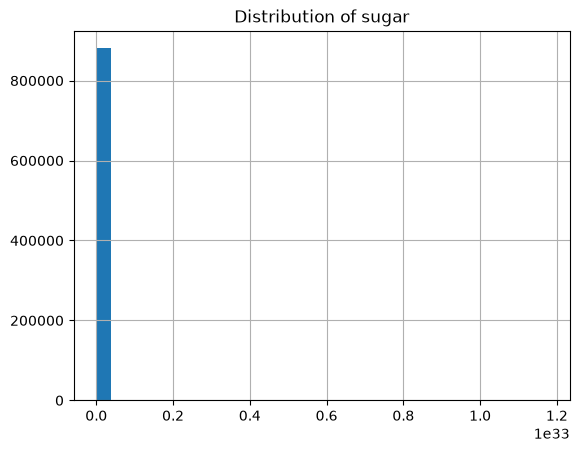

--- salt ---
count    826467.000000
mean          1.278683
std           9.205121
min           0.000000
25%           0.075000
50%           0.550000
75%           1.300000
max        5000.000000
Name: salt_100g, dtype: float64
Missing rate on salt_100g: 33.74 %
54 products have an impossible salt value, i.e. 0.0043 %
                                              product_name    salt_100g
852610   [{'lang': 'main', 'text': 'Capers, Non Pareil'...  5000.000000
1067377  [{'lang': 'main', 'text': 'Roasted Sesame'}, {...  3333.333252
618213   [{'lang': 'main', 'text': 'BCAA Sport'}, {'lan...  2500.000000
665442   [{'lang': 'en', 'text': 'Garden Stix French On...  2150.000000
913527   [{'lang': 'main', 'text': 'Drink mix'}, {'lang...  1387.500000
Raw data for the worst row:
[{'name': 'sodium', 'value': None, '100g': 2000.0, 'serving': None, 'unit': 'g', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'prepared_unit': None}
 {'name': 'fiber', 'value': None, '100g': 

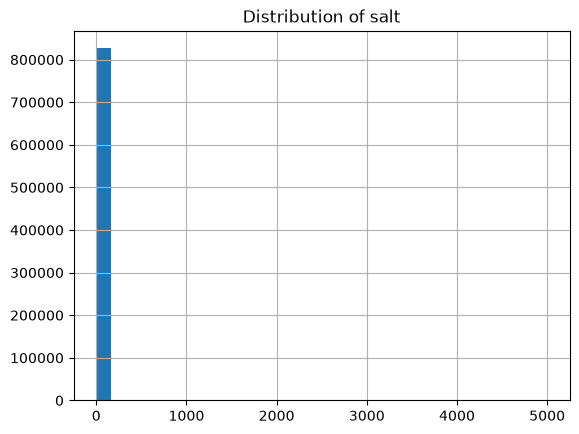

--- energy ---
count    8.878590e+05
mean     1.603036e+10
std      1.510481e+13
min     -1.138600e+02
25%      1.140000e+02
50%      2.620000e+02
75%      4.000000e+02
max      1.423270e+16
Name: energy_kcal_100g, dtype: float64
Missing rate on energy_kcal_100g: 28.82 %
1117 products have an impossible energy value, i.e. 0.0896 %
                                              product_name  energy_kcal_100g
752504   [{'lang': 'main', 'text': 'India Pale Ale'}, {...      1.423270e+16
1183917                                                 []      3.333333e+06
1234368                                                 []      2.490600e+05
1097937          [{'lang': 'fr', 'text': '3336420100097'}]      1.402060e+05
1125074  [{'lang': 'main', 'text': 'Furikaké shiso et s...      4.654210e+04
Raw data for the worst row:
[{'name': 'vitamin-b9', 'value': None, '100g': 4.350000017439015e-05, 'serving': None, 'unit': 'g', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'pre

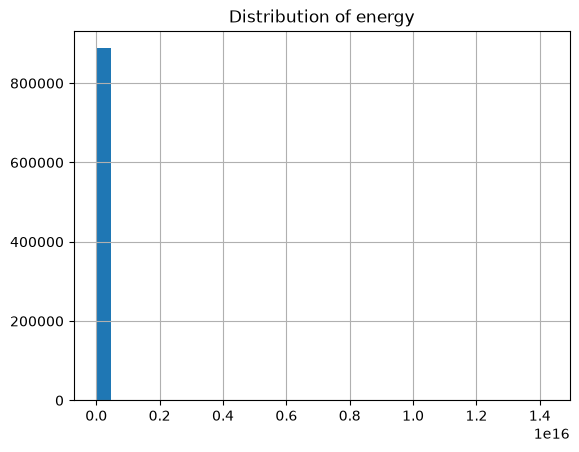

In [56]:
# Extracting product names
france_dataframe["product_name_main"] = france_dataframe["product_name"].apply(extract_main_name)

print(france_dataframe["product_name_main"].nunique(), "unique product names")

# Getting the distribution and outlier values
sugar_results = analyze_distribution(france_dataframe, 'sugars_100g', 0, 100, "sugar")
salt_results = analyze_distribution(france_dataframe, 'salt_100g', 0, 100, "salt")
energy_results = analyze_distribution(france_dataframe, 'energy_kcal_100g', 0, 900, "energy")

In [57]:
columns_to_exclude = ['nutriments', 'product_name', 'countries_tags']

for column in france_dataframe.columns:
    if column in columns_to_exclude:
        print(f'{column:20s} -> (list column, cardinality not directly computable)')
        continue

    nb_unique = france_dataframe[column].nunique()
    print(f'{column:20s} -> {nb_unique:>10,} unique values out of {len(france_dataframe):,} rows')

product_name         -> (list column, cardinality not directly computable)
brands               ->    113,784 unique values out of 1,247,336 rows
code                 ->  1,247,309 unique values out of 1,247,336 rows
nutriments           -> (list column, cardinality not directly computable)
nutriscore_score     ->         70 unique values out of 1,247,336 rows
countries_tags       -> (list column, cardinality not directly computable)
ingredients          ->    319,998 unique values out of 1,247,336 rows
energy_kcal_100g     ->     19,073 unique values out of 1,247,336 rows
sugars_100g          ->     11,557 unique values out of 1,247,336 rows
salt_100g            ->     14,344 unique values out of 1,247,336 rows
product_name_main    ->    734,820 unique values out of 1,247,336 rows


In [58]:
# Number of duplicate barcodes
nb_duplicates = france_dataframe['code'].duplicated().sum()
print(f'Duplicate barcodes: {nb_duplicates}')

duplicate_codes = france_dataframe[france_dataframe['code'].duplicated(keep=False)].sort_values('code')
print(duplicate_codes[['code', 'product_name_main', 'brands']])

Duplicate barcodes: 27
                   code                                  product_name_main  \
4238      0059527070430                                    Goji Snack Bars   
1058458   0059527070430                                               Goji   
4243      0059527171687            Tast Of Nature Pomegranate Granenreep @   
1058459   0059527171687                                        Pomegranate   
4256      0059527401555                     Almond Fruit And Nut Snack Bar   
1058453   0059527401555                                             Almond   
4257      0059527501552                  Cranberry Fruit and Nut Snack Bar   
1058449   0059527501552                                          Cranberry   
4259      0059527601559  Coconut, Cranberry, Brazil Nut Snack Bar Varie...   
1058456   0059527601559                                         Brazil nut   
1056819   2000000151610                                                NaN   
1056829   2000000151610                  

In [59]:
# Collecting all units used per nutrient
units_used = {}

for nutrients_list in france_dataframe['nutriments'].dropna():
    for item in nutrients_list:
        name = item['name']
        unit = item.get('unit')
        units_used.setdefault(name, set()).add(unit)

for name in ['salt', 'sodium', 'sugars', 'energy-kcal', 'energy-kj', 'energy']:
    print(name, '->', units_used.get(name))

salt -> {None, 'mg', 'g', ''}
sodium -> {None, 'mg', 'g'}
sugars -> {None, '', 'g'}
energy-kcal -> {None, 'kcal'}
energy-kj -> {None, 'kJ', 'kj'}
energy -> {None, 'kJ', 'kj', 'kcal'}
